In [1]:
import time
import matplotlib.pyplot as plt 
import os
os.chdir('../')
import torch
import numpy as np
import torch.nn as nn
from typing import List, Tuple, Optional
import matplotlib.pyplot as plt
import random 
import psutil
from decimal import Decimal
import deepwave
import warnings
import torch.nn.functional as F
from functools import partial
from torchaudio.functional import biquad
from scipy.signal import butter
warnings.filterwarnings('ignore')
import os
from ultils.utils import *
from pyramid_loss import gaussian_kernel, create_gaussian_pyramid
os.environ['KMP_DUPLICATE_LIB_OK']='True'


libgomp: Invalid value for environment variable OMP_NUM_THREADS

libgomp: Invalid value for environment variable OMP_NUM_THREADS


In [2]:
gpu_count = torch.cuda.device_count()
print(f"The number of available GPUs is: {gpu_count}")
if torch.cuda.is_available():
    DEVICE = torch.device("cuda:0")  
    print(f"The selected GPU device is: {torch.cuda.get_device_name(DEVICE)}")
else:
    DEVICE = torch.device("cpu")
    print("No available GPUs detected, switched to using CPU")

The number of available GPUs is: 1
The selected GPU device is: NVIDIA GeForce RTX 4090


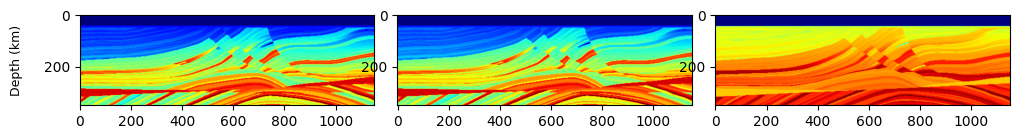

max values: tensor(4766.6040) tensor(2752.) tensor(2626.9998)
min values: tensor(1500.) tensor(800.) tensor(1009.)
model shape: torch.Size([352, 1150]) torch.Size([352, 1150]) torch.Size([352, 1150])


In [3]:
######### load data #########
dx = 10

vp_true = torch.tensor(np.load('./marmousi_model/vp_truex352x1150x10.npy'))
vs_true = torch.tensor(np.load('./marmousi_model/vs_truex352x1150x10.npy'))
rho_true = torch.tensor(np.load('./marmousi_model/rho_truex352x1150x10.npy'))


submarine_deep = 43
submarine_vp = 1500                                      #water layer vp
submarine_vs = 800  ##to obay the CFL condition                                         #water layer vs
submarine_rho = 1009
  
vp_true[:submarine_deep,:] = submarine_vp
vs_true[:submarine_deep,:] = submarine_vs
rho_true[:submarine_deep,:] = submarine_rho


fig, ax = plt.subplots(1, 3, figsize=(12, 16))
fig1 = ax[0].imshow(vp_true.cpu().numpy(), cmap= 'jet',vmin = vp_true.min(),vmax = vp_true.max())
ax[0].set_ylabel("Depth (km)\n",fontsize=9)
fig2 = ax[1].imshow(vs_true.cpu().numpy(), cmap= 'jet',vmin = vs_true.min(),vmax = vs_true.max())
fig3 = ax[2].imshow(rho_true.cpu().numpy(), cmap= 'jet',vmin = rho_true.min(),vmax = rho_true.max())
plt.subplots_adjust(hspace=-0.84,wspace=0.08) 
plt.show()
print("max values:",vp_true.max(),vs_true.max(),rho_true.max())
print("min values:",vp_true.min(),vs_true.min(),rho_true.min())
print("model shape:",vp_true.shape,vs_true.shape,rho_true.shape)

17.387997
tensor(3927.0754, device='cuda:0') tensor(1847.8777, device='cuda:0')
tensor(1009., device='cuda:0') tensor(2409.4448, device='cuda:0')


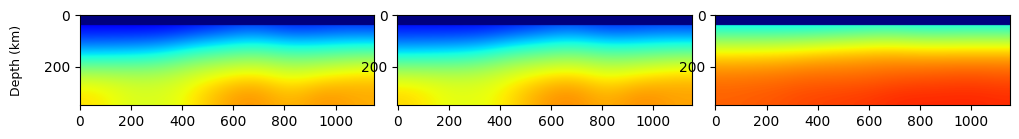

In [4]:
import scipy.ndimage
import scipy.io

sigma = 30

times = 6
if times != 0:
    vp_initial,vs_initial,rho_initial = gaussian_smooth_n_times(vp_true, vs_true, rho_true, sigma, times, DEVICE)
else:
    vp_initial,vs_initial,rho_initial = gaussian_smooth_once(vp_true, vs_true, rho_true, sigma, DEVICE)

snr_vp = ComputeSNR(vp_initial.detach().cpu().numpy(), \
                  vp_true.detach().cpu().numpy())

print(snr_vp)
print(vp_initial.max(),vp_initial.min())
vp_initial[:submarine_deep,:] = submarine_vp
vs_initial[:submarine_deep,:] = submarine_vs
rho_initial[:submarine_deep,:] = submarine_rho

print(rho_initial.min(),rho_initial.max())

fig, ax = plt.subplots(1, 3, figsize=(12, 16))
fig1 = ax[0].imshow(vp_initial.cpu().numpy(), cmap= 'jet',vmin = vp_true.min(),vmax = vp_true.max())
ax[0].set_ylabel("Depth (km)\n",fontsize=9)
fig2 = ax[1].imshow(vs_initial.cpu().numpy(), cmap= 'jet',vmin = vs_true.min(),vmax = vs_true.max())
fig3 = ax[2].imshow(rho_initial.cpu().numpy(), cmap= 'jet',vmin = rho_true.min(),vmax = rho_true.max())
plt.subplots_adjust(hspace=-0.84,wspace=0.08) 
plt.show()

In [5]:
loss_fn = 'l1'  # Options: 'l1', 'l2', 'laploss', 'W1', 'GSOT', 'WF', 'WECI', 'CS'
                # Determines the misfit function between synthetic and observed data

if times != 0:
    ##### save path
    vp_save_path = f'./rec/reconstruction_ms/EFWI_gau_en/init_2/vp/'
    vs_save_path = f'./rec/reconstruction_ms/EFWI_gau_en/init_2/vs/'
    rho_save_path = f'./rec/reconstruction_ms/EFWI_gau_en/init_2/rho/'
    main_path = f'./log_data/log_data_ms/EFWI_gau_en/init_2/'
else:
    vp_save_path = f'./rec/reconstruction_ms/EFWI_gau_en/init_1/vp/'
    vs_save_path = f'./rec/reconstruction_ms/EFWI_gau_en/init_1/vs/'
    rho_save_path = f'./rec/reconstruction_ms/EFWI_gau_en/init_1/rho/'
    main_path = f'./log_data/log_data_ms/EFWI_gau_en/init_1/'


if not os.path.exists(main_path):
    os.makedirs(main_path)

if not os.path.exists(vp_save_path):
    os.makedirs(vp_save_path)
if not os.path.exists(vs_save_path):
    os.makedirs(vs_save_path)
if not os.path.exists(rho_save_path):
    os.makedirs(rho_save_path)
    


In [6]:
Physics = Physics_deepwave                              
                           
model_shape = [vp_true.shape[0], vp_true.shape[1]]                                 
                                                                                       
DT = 0.006                                               
F_PEAK = 8                                              
DH = dx                                                  

inpa = {                                
    'fdom': F_PEAK, 
    'dh': DH,   
    'dt': DT
}

NT = 2500

In [7]:
### load obs and src, src_loc, rec_loc
obs_file_vx = './obs_data/d_obs_vx_src.npy'
obs_file_vy = './obs_data/d_obs_vy_src.npy'
d_obs_vx = torch.tensor(np.load(obs_file_vx))
d_obs_vy = torch.tensor(np.load(obs_file_vy))

src_loc = torch.tensor(np.load('./src_rec_positions/src_loc.npy'))
rec_loc = torch.tensor(np.load('./src_rec_positions/rec_loc.npy'))
src     = torch.tensor(np.load('./sources/src.npy'))

### sum source
num_super_sources = 10
sources_per_super = 10
source_distribution = 'random'# ('random' 或 'uniform')

#### 1.
result = encode_sources(obs_data_vx = d_obs_vx.squeeze(0),
                        obs_data_vy = d_obs_vy.squeeze(0),
                        source_locations = src_loc, 
                        receiver_locations  = rec_loc, 
                        source_functions = src,
                        num_super_sources = num_super_sources,
                        sources_per_super = sources_per_super,
                        source_distribution=source_distribution
                        )

#### 2
print(f"Encoded observation data shape (vx): {result['encoded_obs_data_vx'].shape}")
print(f"Encoded observation data shape (vy): {result['encoded_obs_data_vy'].shape}")
print(f"Encoded source location shape: {result['encoded_source_locations'].shape}")
print(f"Encoded receiver location shape: {result['encoded_receiver_locations'].shape}")
print(f"Encoded source function shape: {result['encoded_source_functions'].shape}")


d_obs_vx_encode = result['encoded_obs_data_vx'].unsqueeze(0).to(DEVICE)
d_obs_vy_encode = result['encoded_obs_data_vy'].unsqueeze(0).to(DEVICE)
src_loc_encode  = result['encoded_source_locations'].to(DEVICE)
rec_loc_encode  = result['encoded_receiver_locations'].to(DEVICE)
src_encode      = result['encoded_source_functions'].to(DEVICE)



Encoded observation data shape (vx): torch.Size([10, 2500, 1130])
Encoded observation data shape (vy): torch.Size([10, 2500, 1130])
Encoded source location shape: torch.Size([10, 10, 2])
Encoded receiver location shape: torch.Size([10, 1130, 2])
Encoded source function shape: torch.Size([10, 10, 2500])


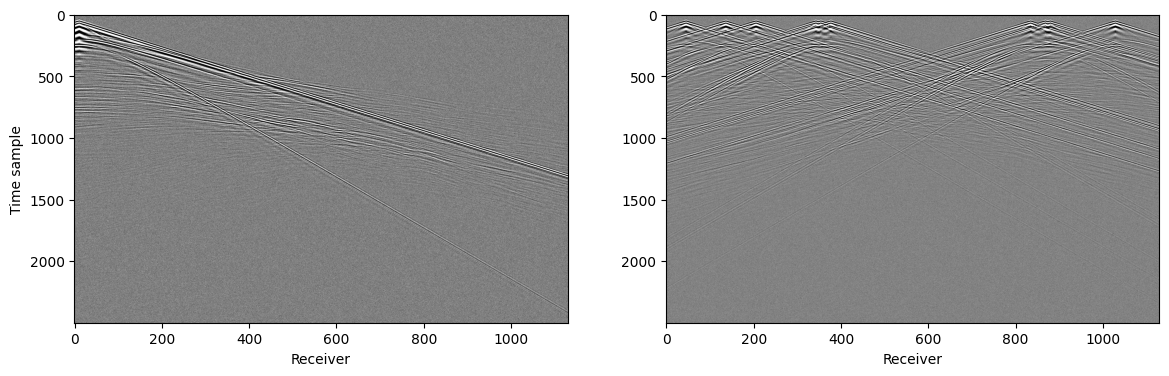

In [8]:

##### show these data
d_obs_vx_plot = d_obs_vx.squeeze(0)
d_obs_vx_en_plot = d_obs_vx_encode.squeeze(0)
vmin, vmax = torch.quantile(d_obs_vx_plot[1],
                            torch.tensor([0.01, 0.99]))
vsmin, vsmax = torch.quantile(d_obs_vx_en_plot[1],
                                 torch.tensor([0.01, 0.99]).to(DEVICE))


fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].imshow(d_obs_vx_plot[1].cpu().detach().numpy(), aspect='auto', cmap='gray',vmin=vmin, vmax=vmax)
ax[0].set_xlabel("Receiver")
ax[0].set_ylabel("Time sample")
ax[1].imshow(d_obs_vx_en_plot[1].cpu().detach().numpy(), aspect='auto', cmap='gray',vmin=vsmin, vmax=vsmax)
ax[1].set_xlabel("Receiver")
plt.subplots_adjust(hspace=0.6)  
plt.show()


In [9]:
vp_initial = vp_initial.to(DEVICE)
vs_initial = vs_initial.to(DEVICE)
rho_initial = rho_initial.to(DEVICE)
vp = vp_initial.requires_grad_(True)
vs = vs_initial.requires_grad_(True)
rho = rho_initial.requires_grad_(True)

criteria = torch.nn.L1Loss(reduction='sum')
criteria_model = torch.nn.L1Loss(reduction='sum')

optimer = torch.optim.Adam([{'params': [vp], 'lr': 6.0},
                            {'params': [vs], 'lr': 4.0},
                            {'params': [rho], 'lr': 2.0}])

In [10]:
all_loss_data = []
all_loss_vx_model = []
all_loss_vy_model = []
all_loss_rho_model = []
all_loss_model =[]
SNR_vp = []
SSIM_vp = []
Loss_vp = []
ERROR_vp = []
SNR_vs = []
SSIM_vs = []
Loss_vs = []
ERROR_vs = []
SNR_rho = []
SSIM_rho = []
Loss_rho = []
ERROR_rho = []
time_each_iter = []
def get_cpu_memory():
    process = psutil.Process(os.getpid())
    mem_info = process.memory_info()
    return mem_info.rss / 1024 ** 2  
    
def get_gpu_memory():
    if torch.cuda.is_available():
        
        return torch.cuda.memory_allocated() / 1024 ** 2
    else:
        return 0
cpu_mem_log = [] 
gpu_mem_log = []

Now inversion on level: 5
Iteration 5 = loss: 0.7098,model loss: 269063976.0000,time:6.91,snr_vp:18.167,snr_vs:18.156,snr_rho:22.561
Iteration 10 = loss: 0.7098,model loss: 269053492.0000,time:6.93,snr_vp:18.167,snr_vs:18.157,snr_rho:22.564
Iteration 15 = loss: 0.7097,model loss: 269043360.0000,time:6.94,snr_vp:18.167,snr_vs:18.159,snr_rho:22.566
Iteration 20 = loss: 0.7096,model loss: 269033396.0000,time:6.94,snr_vp:18.167,snr_vs:18.160,snr_rho:22.569


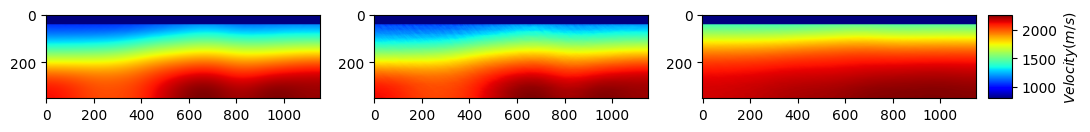

Iteration 25 = loss: 0.7095,model loss: 269023688.0000,time:6.95,snr_vp:18.168,snr_vs:18.161,snr_rho:22.571
Iteration 30 = loss: 0.7095,model loss: 269014264.0000,time:6.94,snr_vp:18.168,snr_vs:18.162,snr_rho:22.573
Iteration 35 = loss: 0.7094,model loss: 269005068.0000,time:6.95,snr_vp:18.168,snr_vs:18.163,snr_rho:22.575
Iteration 40 = loss: 0.7093,model loss: 268996112.0000,time:6.94,snr_vp:18.168,snr_vs:18.164,snr_rho:22.577


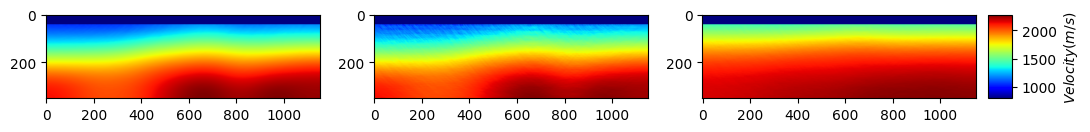

Iteration 45 = loss: 0.7093,model loss: 268987432.0000,time:6.94,snr_vp:18.168,snr_vs:18.164,snr_rho:22.579
Iteration 50 = loss: 0.7092,model loss: 268979080.0000,time:6.92,snr_vp:18.168,snr_vs:18.164,snr_rho:22.581
Now inversion on level: 4
Iteration 5 = loss: 1.4973,model loss: 267994520.0000,time:6.93,snr_vp:18.190,snr_vs:18.223,snr_rho:22.658
Iteration 10 = loss: 1.4792,model loss: 266271032.0000,time:6.95,snr_vp:18.220,snr_vs:18.273,snr_rho:22.744
Iteration 15 = loss: 1.4676,model loss: 264624472.0000,time:6.93,snr_vp:18.250,snr_vs:18.306,snr_rho:22.813
Iteration 20 = loss: 1.4602,model loss: 263128104.0000,time:6.95,snr_vp:18.279,snr_vs:18.332,snr_rho:22.867


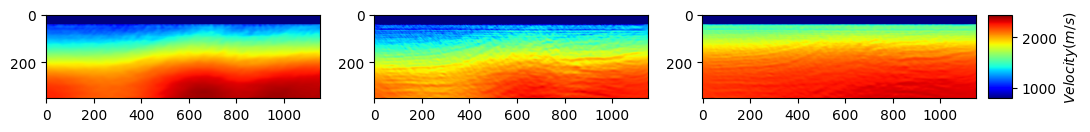

Iteration 25 = loss: 1.4547,model loss: 261779816.0000,time:6.98,snr_vp:18.307,snr_vs:18.355,snr_rho:22.909
Iteration 30 = loss: 1.4507,model loss: 260582816.0000,time:6.96,snr_vp:18.332,snr_vs:18.377,snr_rho:22.942
Iteration 35 = loss: 1.4476,model loss: 259535704.0000,time:6.96,snr_vp:18.355,snr_vs:18.396,snr_rho:22.970
Iteration 40 = loss: 1.4450,model loss: 258605996.0000,time:6.96,snr_vp:18.377,snr_vs:18.413,snr_rho:22.994


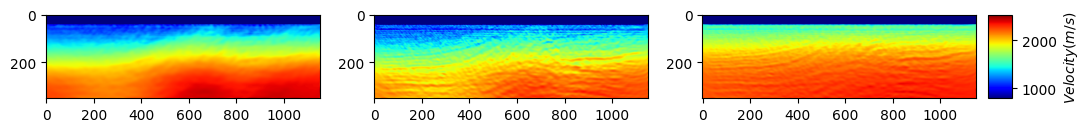

Iteration 45 = loss: 1.4429,model loss: 257758112.0000,time:6.95,snr_vp:18.396,snr_vs:18.426,snr_rho:23.015
Iteration 50 = loss: 1.4410,model loss: 256988372.0000,time:6.95,snr_vp:18.415,snr_vs:18.438,snr_rho:23.034
Now inversion on level: 3
Iteration 5 = loss: 3.6240,model loss: 245424464.0000,time:6.95,snr_vp:18.738,snr_vs:18.895,snr_rho:23.226
Iteration 10 = loss: 3.3101,model loss: 235720580.0000,time:7.97,snr_vp:19.052,snr_vs:19.308,snr_rho:23.310
Iteration 15 = loss: 3.1677,model loss: 228008104.0000,time:7.96,snr_vp:19.330,snr_vs:19.636,snr_rho:23.349
Iteration 20 = loss: 3.0911,model loss: 221813816.0000,time:8.00,snr_vp:19.560,snr_vs:19.893,snr_rho:23.376


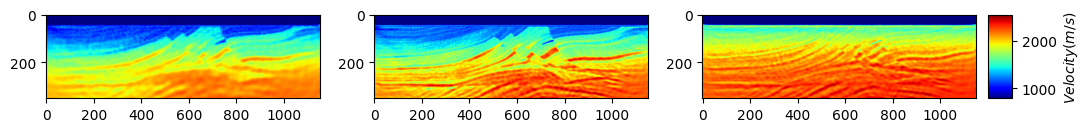

Iteration 25 = loss: 3.0427,model loss: 216791264.0000,time:7.96,snr_vp:19.754,snr_vs:20.106,snr_rho:23.401
Iteration 30 = loss: 3.0029,model loss: 212618608.0000,time:8.04,snr_vp:19.916,snr_vs:20.287,snr_rho:23.428
Iteration 35 = loss: 2.9756,model loss: 209098424.0000,time:7.93,snr_vp:20.057,snr_vs:20.445,snr_rho:23.458
Iteration 40 = loss: 2.9572,model loss: 205992588.0000,time:7.96,snr_vp:20.178,snr_vs:20.582,snr_rho:23.489


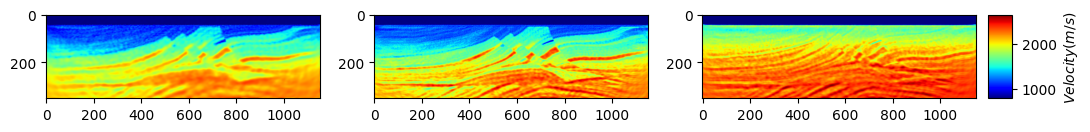

Iteration 45 = loss: 2.9426,model loss: 203314888.0000,time:7.95,snr_vp:20.284,snr_vs:20.708,snr_rho:23.520
Iteration 50 = loss: 2.9303,model loss: 200892184.0000,time:7.93,snr_vp:20.379,snr_vs:20.824,snr_rho:23.551
Now inversion on level: 2
Iteration 5 = loss: 6.9182,model loss: 184835944.0000,time:7.95,snr_vp:20.904,snr_vs:21.354,snr_rho:23.683
Iteration 10 = loss: 6.5971,model loss: 174955212.0000,time:7.96,snr_vp:21.261,snr_vs:21.650,snr_rho:23.823
Iteration 15 = loss: 6.5949,model loss: 168803700.0000,time:7.94,snr_vp:21.503,snr_vs:21.840,snr_rho:23.935
Iteration 20 = loss: 6.4449,model loss: 164665416.0000,time:7.95,snr_vp:21.683,snr_vs:21.992,snr_rho:24.025


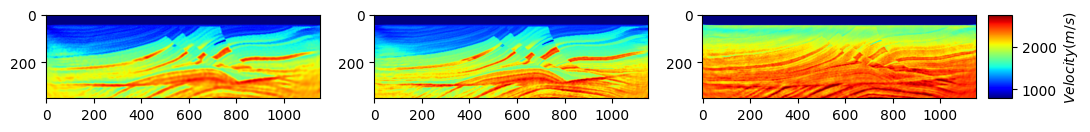

Iteration 25 = loss: 6.1190,model loss: 161303616.0000,time:7.98,snr_vp:21.830,snr_vs:22.102,snr_rho:24.100
Iteration 30 = loss: 6.2358,model loss: 158497020.0000,time:8.05,snr_vp:21.960,snr_vs:22.207,snr_rho:24.166
Iteration 35 = loss: 6.2015,model loss: 156205052.0000,time:7.97,snr_vp:22.069,snr_vs:22.294,snr_rho:24.228
Iteration 40 = loss: 6.0492,model loss: 154262276.0000,time:7.97,snr_vp:22.165,snr_vs:22.373,snr_rho:24.284


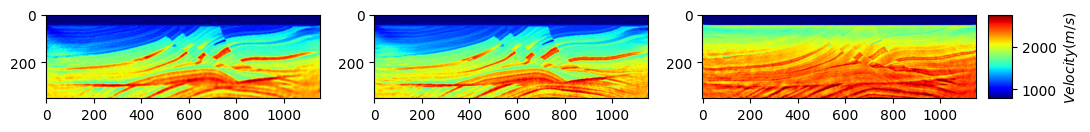

Iteration 45 = loss: 5.9966,model loss: 152545980.0000,time:7.97,snr_vp:22.248,snr_vs:22.445,snr_rho:24.334
Iteration 50 = loss: 6.0741,model loss: 151088884.0000,time:7.96,snr_vp:22.322,snr_vs:22.504,snr_rho:24.382
Now inversion on level: 1
Iteration 5 = loss: 13.8547,model loss: 148208940.0000,time:7.95,snr_vp:22.452,snr_vs:22.617,snr_rho:24.452
Iteration 10 = loss: 15.5843,model loss: 145904392.0000,time:7.97,snr_vp:22.550,snr_vs:22.708,snr_rho:24.510
Iteration 15 = loss: 13.5991,model loss: 144321252.0000,time:7.98,snr_vp:22.619,snr_vs:22.754,snr_rho:24.563
Iteration 20 = loss: 14.0112,model loss: 143027832.0000,time:7.95,snr_vp:22.680,snr_vs:22.797,snr_rho:24.602


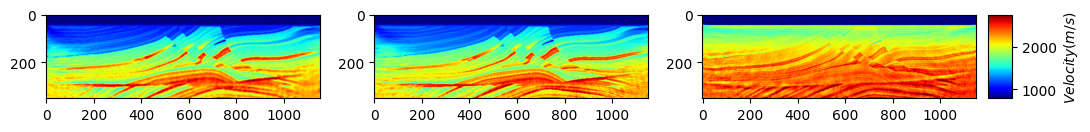

Iteration 25 = loss: 13.6774,model loss: 141953828.0000,time:8.01,snr_vp:22.733,snr_vs:22.842,snr_rho:24.636
Iteration 30 = loss: 13.5947,model loss: 141131280.0000,time:7.96,snr_vp:22.778,snr_vs:22.874,snr_rho:24.669
Iteration 35 = loss: 13.4900,model loss: 140340544.0000,time:8.03,snr_vp:22.818,snr_vs:22.899,snr_rho:24.702
Iteration 40 = loss: 13.4805,model loss: 139673864.0000,time:8.01,snr_vp:22.853,snr_vs:22.927,snr_rho:24.730


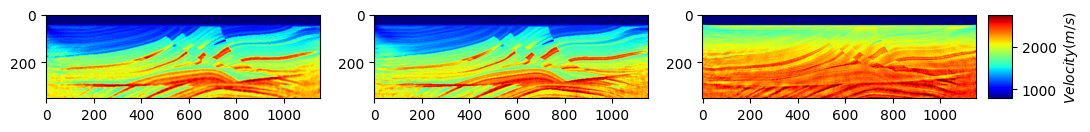

Iteration 45 = loss: 13.4114,model loss: 139097856.0000,time:7.97,snr_vp:22.885,snr_vs:22.954,snr_rho:24.755
Iteration 50 = loss: 13.3639,model loss: 138631692.0000,time:8.05,snr_vp:22.912,snr_vs:22.975,snr_rho:24.780
Now inversion on level: 0
Iteration 5 = loss: 70.7934,model loss: 138210320.0000,time:7.98,snr_vp:22.926,snr_vs:22.988,snr_rho:24.794
Iteration 10 = loss: 70.7946,model loss: 138053172.0000,time:7.98,snr_vp:22.935,snr_vs:22.992,snr_rho:24.801
Iteration 15 = loss: 70.7439,model loss: 137932548.0000,time:8.00,snr_vp:22.942,snr_vs:22.998,snr_rho:24.807
Iteration 20 = loss: 70.7314,model loss: 137826360.0000,time:8.05,snr_vp:22.949,snr_vs:23.004,snr_rho:24.813


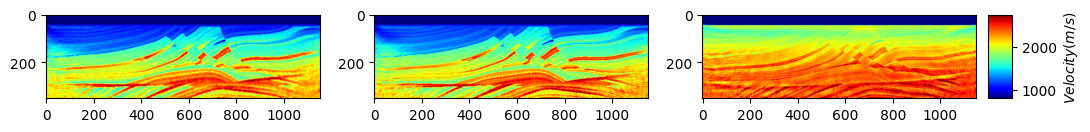

Iteration 25 = loss: 70.7214,model loss: 137732060.0000,time:7.98,snr_vp:22.955,snr_vs:23.009,snr_rho:24.819
Iteration 30 = loss: 70.7190,model loss: 137646136.0000,time:7.96,snr_vp:22.961,snr_vs:23.013,snr_rho:24.824
Iteration 35 = loss: 70.7174,model loss: 137564864.0000,time:8.11,snr_vp:22.966,snr_vs:23.018,snr_rho:24.829
Iteration 40 = loss: 70.7160,model loss: 137488608.0000,time:7.98,snr_vp:22.972,snr_vs:23.022,snr_rho:24.835


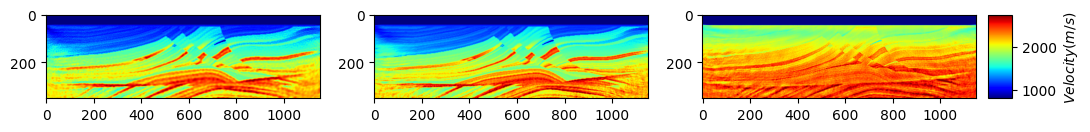

Iteration 45 = loss: 70.7145,model loss: 137418884.0000,time:7.96,snr_vp:22.977,snr_vs:23.026,snr_rho:24.840
Iteration 50 = loss: 70.7133,model loss: 137353760.0000,time:7.95,snr_vp:22.982,snr_vs:23.030,snr_rho:24.845
Running complete in 38m  52s


In [11]:
# Run optimisation/inversion

# import time
t_start = time.time()
mini_batches = 5
ITERATION = 50 


levels  = 6

levels_1 = np.arange(0,levels,1)

for level in reversed(levels_1):
    print('Now inversion on level:',level)

    for iter in range(ITERATION):
        loss_data_minibatch = []
        
        time_each_bath_start = time.time()
        for batch in range(mini_batches):
       
            optimer.zero_grad()
        
            src_loc_batch = src_loc_encode[batch::mini_batches].to(DEVICE)
            rec_loc_batch = rec_loc_encode[batch::mini_batches].to(DEVICE)
            src_batch = src_encode[batch::mini_batches].to(DEVICE) ## for true source
                
            physics = Physics(inpa['dh'], inpa['dt'],inpa['fdom'] ,size=NT,src=src_batch,
                        src_loc=src_loc_batch, rec_loc=rec_loc_batch
                        )

            with torch.no_grad():
            
                vp[:submarine_deep,:] = submarine_vp
                vs[:submarine_deep,:] = submarine_vs
                rho[:submarine_deep,:] = submarine_rho
            
                vp[vp>vp_true.max()] = vp_true.max()
                vp[vp<vp_true.min()] = vp_true.min()
        
                vs[vs>vs_true.max()] = vs_true.max()
                vs[vs<vs_true.min()] = vs_true.min()
        
                rho[rho>rho_true.max()] = rho_true.max()
                rho[rho<rho_true.min()] = rho_true.min()
               
                vp = vp.requires_grad_(True)
                vs = vs.requires_grad_(True)
                rho = rho.requires_grad_(True)          
        

            vp = vp.to(DEVICE)
            vs = vs.to(DEVICE)
            rho = rho.to(DEVICE)
            
    
            taux_est = physics(vp,vs,rho) 
            taux_vx_est_filtered = taux_est[0].to(DEVICE)
            taux_vy_est_filtered = taux_est[1].to(DEVICE)
            
            
            kernel_size = 5
            channels = taux_vx_est_filtered.shape[1]
            sigma = 3
            dtype = torch.float
            kernel = gaussian_kernel(size=kernel_size, channels=channels, sigma=sigma, dtype=dtype, device=DEVICE)
            
            
            pyramids_taux_vx_est_filtered = create_gaussian_pyramid(taux_vx_est_filtered, kernel=kernel, levels=levels
                                                        )
            pyramids_taux_vy_est_filtered = create_gaussian_pyramid(taux_vy_est_filtered, kernel=kernel, levels=levels
                                                        )
            
            taux_est_all = torch.cat((pyramids_taux_vx_est_filtered[level],pyramids_taux_vy_est_filtered[level]),dim=1).to(DEVICE)
            #print(taux_est_all.shape)
            #print(taux_est_all)
            d_obs_vx_filtered = d_obs_vx_encode[:, batch::mini_batches].to(DEVICE)
            d_obs_vy_filtered = d_obs_vy_encode[:, batch::mini_batches].to(DEVICE)
            
            pyramids_d_obs_vx_filtered = create_gaussian_pyramid(d_obs_vx_filtered, kernel=kernel, levels=levels
                                                        )
            pyramids_d_obs_vy_filtered = create_gaussian_pyramid(d_obs_vy_filtered, kernel=kernel, levels=levels
                                                        )
            
            d_obs_filtered_all = torch.cat((pyramids_d_obs_vx_filtered[level],pyramids_d_obs_vy_filtered[level]),dim=1).to(DEVICE)


            if loss_fn == 'l1':
                criteria = torch.nn.L1Loss(reduction='mean')
                loss_data = 1.0e10*criteria(taux_est_all, d_obs_filtered_all)
            if loss_fn == 'l2':
                criteria = torch.nn.MSELoss(reduction='mean')
                loss_data = 1.0e12*criteria(taux_est_all, d_obs_filtered_all)
            loss = loss_data
        
            loss.backward()
        
            optimer.step()
        
     
        all_loss_data.append(loss_data.detach().cpu().item())
        time_each_bath_end = time.time()
        time_each_iter.append(time_each_bath_end - time_each_bath_start)
        
        mem_now_cpu = get_cpu_memory()
        cpu_mem_log.append(mem_now_cpu)
        mem_now_gpu = get_gpu_memory()
        gpu_mem_log.append(mem_now_gpu)
        
        with torch.no_grad():
            all_loss_vx_model.append(
                criteria_model(vp.cpu(),vp_true.cpu()).detach().numpy().item()
            )
        
            all_loss_vy_model.append(
                criteria_model(vs.cpu(),vs_true.cpu()).detach().numpy().item()
                )
            all_loss_rho_model.append(
                criteria_model(rho.cpu(),rho_true.cpu()).detach().numpy().item()
            )
            all_loss_model.append(
                criteria_model(vp.cpu(),vp_true.cpu()).detach().numpy().item()+ \
                criteria_model(vp.cpu(),vp_true.cpu()).detach().numpy().item()+ \
                criteria_model(rho.cpu(),rho_true.cpu()).detach().numpy().item()
            )
    
        snr_vp = ComputeSNR(vp.detach().cpu().numpy(), \
                  vp_true.detach().cpu().numpy())
        SNR_vp = np.append(SNR_vp, snr_vp)
        snr_vs = ComputeSNR(vs.detach().cpu().numpy(), \
                  vs_true.detach().cpu().numpy())
        SNR_vs = np.append(SNR_vs, snr_vs)
        snr_rho = ComputeSNR(rho.detach().cpu().numpy(), \
                  rho_true.detach().cpu().numpy())
        SNR_rho = np.append(SNR_rho, snr_rho)


        if (iter+1)%5 == 0:
            print(f"Iteration {iter + 1} = loss: {all_loss_data[-1]:.4f},model loss: {all_loss_model[-1]:.4f},time:{time_each_iter[-1]:.2f},snr_vp:{SNR_vp[-1]:.3f},snr_vs:{SNR_vs[-1]:.3f},snr_rho:{SNR_rho[-1]:.3f}")

        if (iter+1)%10==0:
            np.save(vp_save_path + 'recx_iter_%s_%s.npy' % (iter + 1, level), vp.cpu().detach().numpy())
            np.save(vs_save_path + 'recx_iter_%s_%s.npy' % (iter + 1, level), vs.cpu().detach().numpy())
            np.save(rho_save_path + 'recx_iter_%s_%s.npy' % (iter + 1, level), rho.cpu().detach().numpy())
        if (iter+1)%20 == 0:
        
            fig, ax = plt.subplots(1,3,figsize=(12, 6))
            im0 = ax[0].imshow(vp.squeeze(0).detach().cpu(), 
                          cmap="jet") 
            im1 = ax[1].imshow(vs.squeeze(0).detach().cpu(), 
                          cmap="jet") 
            im2 = ax[2].imshow(rho.squeeze(0).detach().cpu(), 
                          cmap="jet") 
            points = ax[1].get_position().get_points()
            dy = points[1, 1] - points[0, 1]

            cax = fig.add_axes([0.91, points[0, 1], 0.02, dy])
            cax.yaxis.set_ticks_position("right")
            cbar = fig.colorbar(im1, cax=cax, orientation="vertical", 
                            extend="neither", label="$Velocity (m/s)$"
                            )
            plt.show()
t_end = time.time()
elapsed_time = t_end - t_start
print('Running complete in {:.0f}m  {:.0f}s' .format(elapsed_time //60 , elapsed_time % 60))

In [12]:
#print(all_loss_data)
### path for log data

with torch.no_grad():
    
    np.savetxt(main_path+'all_loss_data.txt', all_loss_data,delimiter=',')
    np.savetxt(main_path+'all_loss_model.txt', all_loss_model, delimiter=',')
    np.savetxt(main_path+'all_loss_vp_model.txt', all_loss_vx_model, delimiter=',')
    np.savetxt(main_path+'all_loss_vs_model.txt', all_loss_vy_model, delimiter=',')
    np.savetxt(main_path+'all_loss_rho_model.txt', all_loss_rho_model, delimiter=',')
    
    np.savetxt(main_path+'vp_snr.txt', SNR_vp,delimiter=',')
    np.savetxt(main_path+'vs_snr.txt', SNR_vs,delimiter=',')
    np.savetxt(main_path+'rho_snr.txt', SNR_rho,delimiter=',')
    
    
    np.savetxt(main_path+'time.txt',time_each_iter , delimiter=',')
    
    np.savetxt(main_path+'cpu_men_log.txt',cpu_mem_log , delimiter=',')
    np.savetxt(main_path+'gpu_men_log.txt',gpu_mem_log , delimiter=',')
